In [24]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_squared_error
import matplotlib.pyplot as plt 
import yfinance as yf
from sklearn.linear_model import LinearRegression

In [25]:
ticker = "AAPL"
data = yf.download('AAPL', period='10y')
data=data[["Open","High","Low","Close","Volume"]]

[*********************100%***********************]  1 of 1 completed


In [26]:
# Feature Engineering
# Add previous day features

data['Prev_Close'] = data['Close'].shift(1)
data['Prev_Open'] = data['Open'].shift(1)
data['Prev_High'] = data['High'].shift(1)
data['Prev_Low'] = data['Low'].shift(1)
data['Prev_Volume'] = data['Volume'].shift(1)

In [27]:
# Add Moving Averages
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

In [28]:
# Target variable
data['Target'] = data['Close']

In [29]:
data = data.dropna()

In [30]:
# Features and target
X = data[['Prev_Open', 'Prev_High', 'Prev_Low', 'Prev_Close', 'Prev_Volume', 'MA10', 'MA50']]
y = data['Target']

In [31]:

# Step 4: Split Data and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:

# Step 5: Train Models
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [33]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

In [34]:
# Step 6: Evaluate Models
def evaluate(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{model_name} RMSE: {rmse}")

evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_lr, "Linear Regression")


Random Forest RMSE: 45.03092245572885
Linear Regression RMSE: 3.9517845802956475


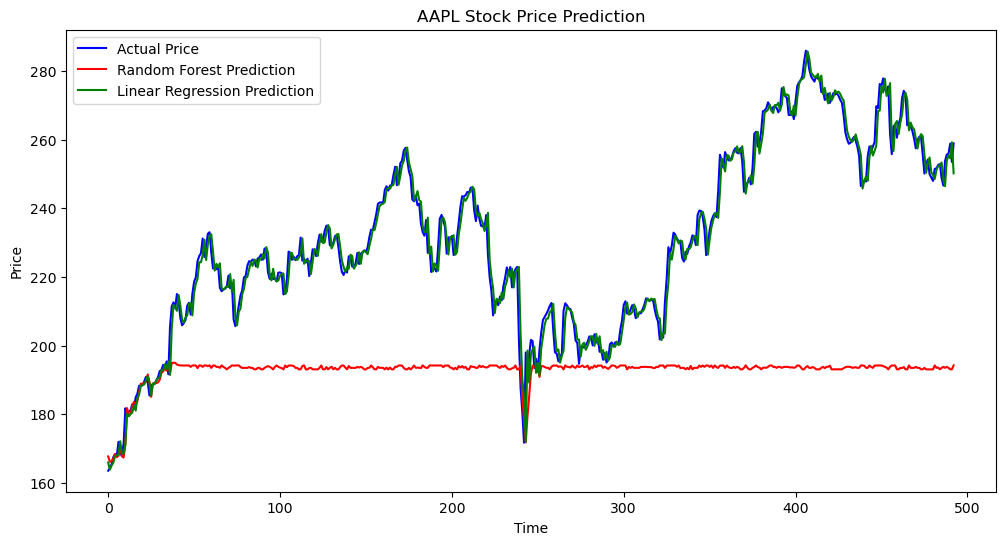

In [36]:
# Step 7: Plot Predictions
plt.figure(figsize=(12,6))
plt.plot(y_test.values, color='blue', label='Actual Price')
plt.plot(y_pred_rf, color='red', label='Random Forest Prediction')
plt.plot(y_pred_lr, color='green', label='Linear Regression Prediction')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()